# Comparative Analysis — Beginner vs Expert, Normal vs Constrained Decoding

This notebook compares the four result CSV files generated by the pipeline:

- `outputs/results_beginner.csv`
- `outputs/results_beginner_CD.csv`
- `outputs/results_expert.csv`
- `outputs/results_expert_CD.csv`

It mirrors the Stage 4 analysis notebook, but focuses on cross-file comparisons, paired deltas, and the biggest row-level changes.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Load the four result files

In [2]:
RESULT_FILES = {
    "BEGINNER / normal": Path("outputs/results_beginner.csv"),
    "BEGINNER / constrained decoding": Path("outputs/results_beginner_CD.csv"),
    "EXPERT / normal": Path("outputs/results_expert.csv"),
    "EXPERT / constrained decoding": Path("outputs/results_expert_CD.csv"),
}

frames = []
for label, path in RESULT_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing result file: {path}")

    frame = pd.read_csv(path)
    frame["experiment"] = label
    frame["generation_mode"] = "constrained_decoding" if path.stem.endswith("_CD") else "normal"
    frame["example_id"] = range(len(frame))
    frame["explanation_word_count"] = frame["explanation"].fillna("").str.split().str.len()
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
metric_cols = [
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "smog_index",
    "lime_coverage",
    "ontology_hit_rate",
]
expected_columns = [
    "text",
    "predicted_class",
    "confidence",
    "user_category",
    "ablation_mode",
    "explanation",
    "lime_coverage",
    "ontology_hit_rate",
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "smog_index",
]
missing = sorted(set(expected_columns) - set(df.columns))
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

print(f"Loaded {len(RESULT_FILES)} files and {len(df)} total rows.")
display(df.groupby("experiment").size().to_frame("rows"))

Loaded 4 files and 200 total rows.


,rows
experiment,
BEGINNER / constrained decoding,50
BEGINNER / normal,50
EXPERT / constrained decoding,50
EXPERT / normal,50


## 3. Aggregate comparison by file

,flesch_reading_ease,flesch_kincaid_grade,smog_index,lime_coverage,ontology_hit_rate,explanation_word_count
experiment,,,,,,
BEGINNER / constrained decoding,21.732,14.972,15.785,0.630,0.64,59.42
BEGINNER / normal,20.035,15.274,16.062,0.633,0.64,58.36
EXPERT / constrained decoding,14.732,16.144,16.776,0.633,0.64,69.14
EXPERT / normal,7.845,17.052,17.442,0.660,0.66,66.78


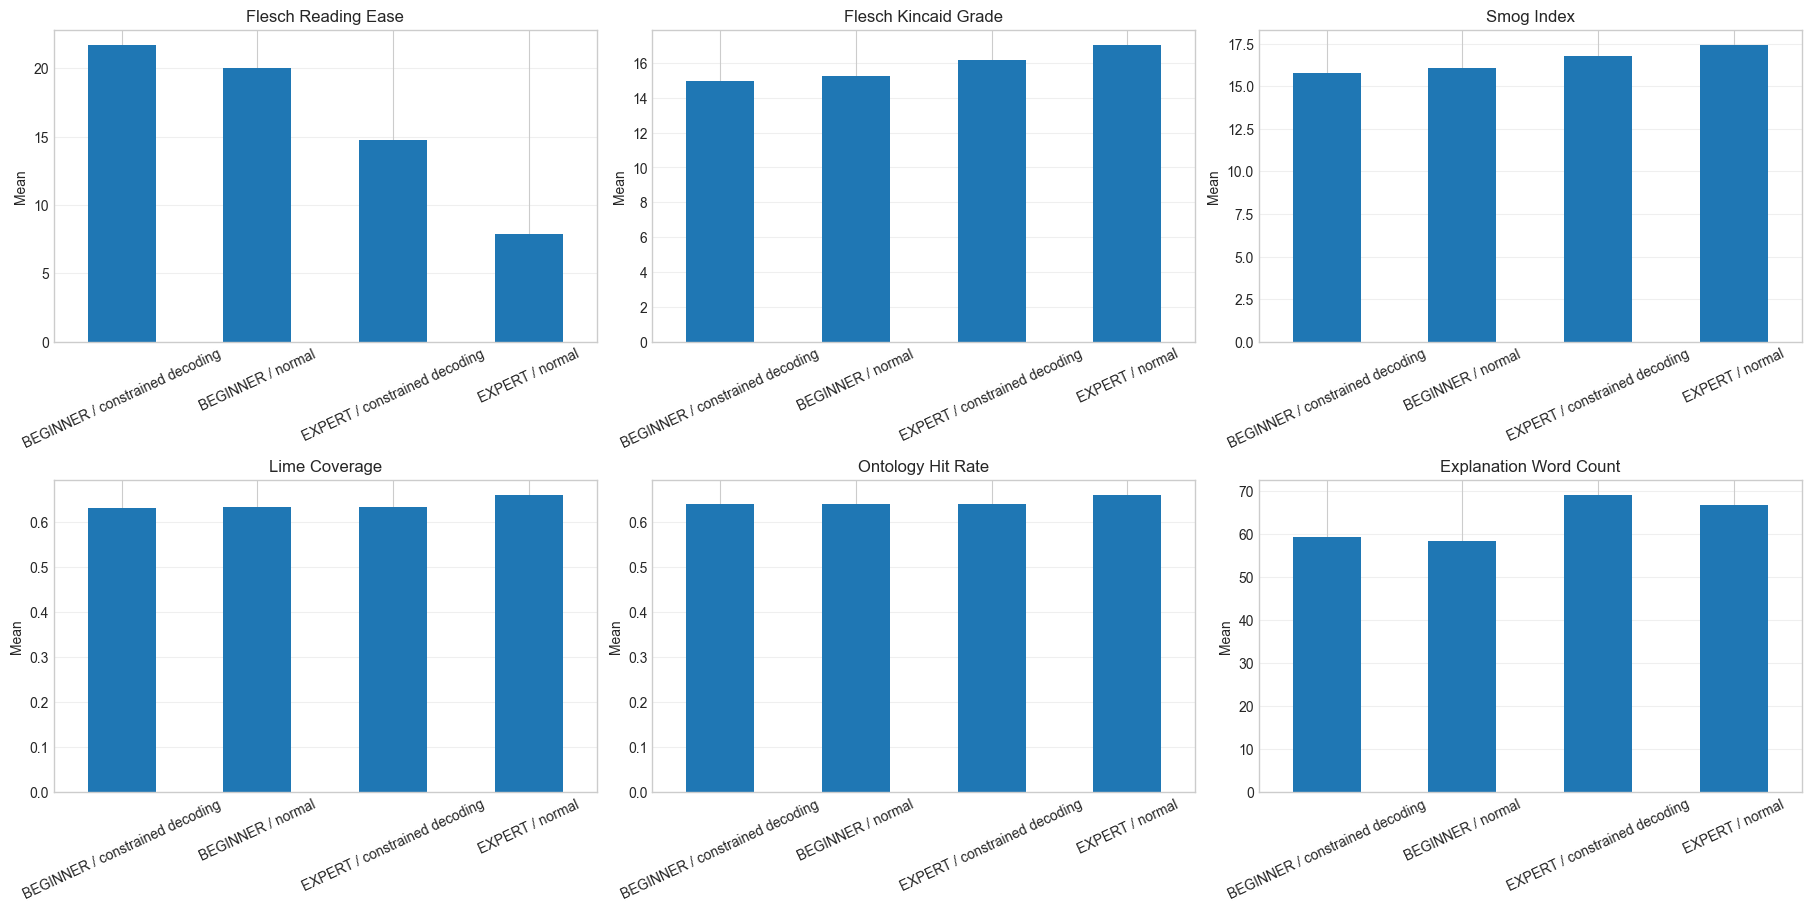

In [3]:
summary_by_file = (
    df.groupby("experiment")[metric_cols + ["explanation_word_count"]]
    .mean()
    .round(3)
)
display(summary_by_file)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
plot_metrics = metric_cols + ["explanation_word_count"]
for ax, metric in zip(axes.ravel(), plot_metrics):
    summary_by_file[metric].plot(kind="bar", ax=ax, color="#1f77b4")
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Mean")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(True, axis="y", alpha=0.3)
plt.show()

## 4. Beginner vs expert comparison within each decoding mode

In [4]:
mode_summary = (
    df.groupby(["generation_mode", "user_category"])[metric_cols + ["explanation_word_count"]]
    .mean()
    .round(3)
)
display(mode_summary)

flesch_reading_ease  flesch_kincaid_grade  \
generation_mode      user_category                                              
constrained_decoding BEGINNER                    21.732                14.972   
                     EXPERT                      14.732                16.144   
normal               BEGINNER                    20.035                15.274   
                     EXPERT                       7.845                17.052   

                                    smog_index  lime_coverage  \
generation_mode      user_category                              
constrained_decoding BEGINNER           15.785          0.630   
                     EXPERT             16.776          0.633   
normal               BEGINNER           16.062          0.633   
                     EXPERT             17.442          0.660   

                                    ontology_hit_rate  explanation_word_count  
generation_mode      user_category                                             
constrained_decoding BEGINNER                    0.64                   59.42  
                     EXPERT                      0.64                   69.14  
normal               BEGINNER                    0.64                   58.36  
                     EXPERT                      0.66                   66.78

## 5. Paired comparison: constrained decoding vs normal

In [5]:
def paired_comparison(audience: str) -> pd.DataFrame:
    normal = (
        df[(df["user_category"] == audience) & (df["generation_mode"] == "normal")]
        .sort_values("example_id")
        .reset_index(drop=True)
    )
    cd = (
        df[(df["user_category"] == audience) & (df["generation_mode"] == "constrained_decoding")]
        .sort_values("example_id")
        .reset_index(drop=True)
    )

    if len(normal) != len(cd):
        raise ValueError(
            f"{audience} has {len(normal)} normal rows and {len(cd)} constrained-decoding rows."
        )

    left_cols = ["example_id", "text", "predicted_class", "confidence", "explanation", "explanation_word_count"] + metric_cols
    merged = normal[left_cols].merge(
        cd[left_cols],
        on="example_id",
        suffixes=("_normal", "_cd"),
        how="inner",
    )

    for metric in metric_cols + ["confidence", "explanation_word_count"]:
        merged[f"{metric}_delta"] = merged[f"{metric}_cd"] - merged[f"{metric}_normal"]

    return merged

paired = {
    audience: paired_comparison(audience)
    for audience in sorted(df["user_category"].dropna().unique())
}

delta_summary = pd.DataFrame(
    {
        audience: table[[f"{metric}_delta" for metric in metric_cols + ["confidence", "explanation_word_count"]]].mean()
        for audience, table in paired.items()
    }
).T.round(3)
display(delta_summary)

for audience, table in paired.items():
    print(f"\n{audience} examples: top 5 largest readability improvements by constrained decoding")
    ranked = table.sort_values("flesch_reading_ease_delta", ascending=False)[
        [
            "example_id",
            "text_normal",
            "predicted_class_normal",
            "flesch_reading_ease_normal",
            "flesch_reading_ease_cd",
            "flesch_reading_ease_delta",
            "flesch_kincaid_grade_normal",
            "flesch_kincaid_grade_cd",
            "smog_index_normal",
            "smog_index_cd",
            "lime_coverage_normal",
            "lime_coverage_cd",
            "ontology_hit_rate_normal",
            "ontology_hit_rate_cd",
        ]
    ].head(5)
    display(ranked)

,flesch_reading_ease_delta,flesch_kincaid_grade_delta,smog_index_delta,lime_coverage_delta,ontology_hit_rate_delta,confidence_delta,explanation_word_count_delta
BEGINNER,1.696,-0.302,-0.277,-0.003,0.00,0.0,1.06
EXPERT,6.887,-0.908,-0.667,-0.027,-0.02,0.0,2.36



BEGINNER examples: top 5 largest readability improvements by constrained decoding


,example_id,text_normal,predicted_class_normal,flesch_reading_ease_normal,flesch_reading_ease_cd,flesch_reading_ease_delta,flesch_kincaid_grade_normal,flesch_kincaid_grade_cd,smog_index_normal,smog_index_cd,lime_coverage_normal,lime_coverage_cd,ontology_hit_rate_normal,ontology_hit_rate_cd
21,21,Effect of increased left atrial pressure on breathing frequency in anestheti...,Cardiovascular diseases,-11.430000,33.288810,44.718810,18.580000,14.412857,17.122413,14.554593,0.0,1.0,0.0,1.0
14,14,The role of elective lymph node dissection in the management of patients wit...,Neoplasms,17.382143,54.406667,37.024524,14.312857,10.461799,14.554593,13.707051,0.0,1.0,0.0,1.0
39,39,Circadian variations in myocardial ischemia. Implications for management. Ex...,Cardiovascular diseases,-11.430000,25.576496,37.006496,18.580000,14.101514,17.122413,14.906228,0.0,1.0,0.0,1.0
12,12,Patient age and results of balloon aortic valvuloplasty: the Mansfield Scien...,Cardiovascular diseases,16.129130,52.653696,36.524566,16.723478,9.840354,17.693802,11.602472,1.0,1.0,1.0,1.0
2,2,Endometriosis associated with massive ascites and absence of pelvic peritone...,Digestive system diseases,11.741916,40.619423,28.877507,21.186039,12.438077,20.267339,13.023867,1.0,1.0,1.0,1.0



EXPERT examples: top 5 largest readability improvements by constrained decoding


,example_id,text_normal,predicted_class_normal,flesch_reading_ease_normal,flesch_reading_ease_cd,flesch_reading_ease_delta,flesch_kincaid_grade_normal,flesch_kincaid_grade_cd,smog_index_normal,smog_index_cd,lime_coverage_normal,lime_coverage_cd,ontology_hit_rate_normal,ontology_hit_rate_cd
4,4,Salvage chemotherapy for patients with germ cell tumors. The Memorial Sloan-...,Neoplasms,12.496642,38.386842,25.890201,16.671175,12.625263,18.243606,15.579742,1.0,1.0,1.0,1.0
0,0,Normalization of ventilation/perfusion relationships after liver transplanta...,Digestive system diseases,5.532500,31.371604,25.839104,16.462500,13.901861,17.122413,15.112258,0.0,1.0,0.0,1.0
13,13,How ancient is temporal arteritis? Realism is one of the characteristics of ...,Cardiovascular diseases,6.652727,31.807083,25.154355,17.796818,14.238606,17.971250,15.381576,1.0,1.0,1.0,1.0
45,45,Neuro-ophthalmic manifestations of human immunodeficiency virus infection. B...,Neoplasms,17.116569,41.504190,24.387621,16.502941,13.122060,16.322122,14.906228,1.0,1.0,1.0,1.0
27,27,Histochemical demonstration of 5'-nucleotidase activity in inflammatory musc...,General pathological conditions,-6.166379,18.102616,24.268994,20.143789,18.125105,20.503739,19.032713,1.0,1.0,1.0,1.0


## 6. Save combined comparison tables

In [6]:
COMPARATIVE_RESULTS_PATH = Path("outputs/comparative_analysis.csv")
SUMMARY_PATH = Path("outputs/comparative_summary.csv")
DELTA_PATH = Path("outputs/comparative_deltas.csv")

df.to_csv(COMPARATIVE_RESULTS_PATH, index=False)
summary_by_file.to_csv(SUMMARY_PATH)
delta_summary.to_csv(DELTA_PATH)

print(f"Saved combined rows to {COMPARATIVE_RESULTS_PATH}")
print(f"Saved summary table to {SUMMARY_PATH}")
print(f"Saved paired deltas to {DELTA_PATH}")

Saved combined rows to outputs\comparative_analysis.csv
Saved summary table to outputs\comparative_summary.csv
Saved paired deltas to outputs\comparative_deltas.csv
